To evaluate the trained YOLOv8 Instance Segmentation model on unseen images by detecting tomatoes, classifying them as ripe or unripe, generating segmentation masks, counting detected tomatoes, and visualizing the predictions.

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.6 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Loading Trained Model

In [4]:
model = YOLO("/content/drive/MyDrive/tomato_project/training/tomato_segmentation/weights/best.pt")

print("Model Loaded Successfully!")

Model Loaded Successfully!


###Select a Test image

In [21]:
image_path = "/content/drive/MyDrive/tomato_project/inference_images/image2.jpg"

In [22]:
image_path1 = "/content/drive/MyDrive/tomato_project/inference_images/image1.jpg"

In [29]:
image_path2 = "/content/drive/MyDrive/tomato_project/inference_images/image3.avif"

In [24]:
image_path3 = "/content/drive/MyDrive/tomato_project/inference_images/image4.jpg"

In [25]:
image_path4 = "/content/drive/MyDrive/tomato_project/inference_images/image5.jpg"

###Prediction

In [11]:
results = model.predict(
    source=image_path,
    conf=0.50,
    save=True,
    imgsz=640
)


image 1/1 /content/drive/MyDrive/tomato_project/inference_images/image2.jpg: 640x448 3 unripes, 12 ripes, 188.7ms
Speed: 2.6ms preprocess, 188.7ms inference, 28.9ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/segment/predict


In [33]:
results1 = model.predict(
    source=image_path2,
    conf=0.50,
    save=True,
    imgsz=640
)


image 1/1 /content/drive/MyDrive/tomato_project/inference_images/image3.avif: 640x448 1 unripe, 6 ripes, 271.8ms
Speed: 4.2ms preprocess, 271.8ms inference, 16.4ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/segment/predict


In [34]:
results2 = model.predict(
    source=image_path1,
    conf=0.50,
    save=True,
    imgsz=640
)


image 1/1 /content/drive/MyDrive/tomato_project/inference_images/image1.jpg: 448x640 1 unripe, 2 ripes, 175.4ms
Speed: 2.6ms preprocess, 175.4ms inference, 8.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/predict


In [35]:
results3 = model.predict(
    source=image_path3,
    conf=0.50,
    save=True,
    imgsz=640
)


image 1/1 /content/drive/MyDrive/tomato_project/inference_images/image4.jpg: 640x448 2 unripes, 9 ripes, 173.6ms
Speed: 2.4ms preprocess, 173.6ms inference, 15.5ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/segment/predict


In [36]:
results4 = model.predict(
    source=image_path4,
    conf=0.50,
    save=True,
    imgsz=640
)


image 1/1 /content/drive/MyDrive/tomato_project/inference_images/image5.jpg: 640x448 5 ripes, 175.0ms
Speed: 2.4ms preprocess, 175.0ms inference, 7.3ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/segment/predict


###Display the Predicted Image

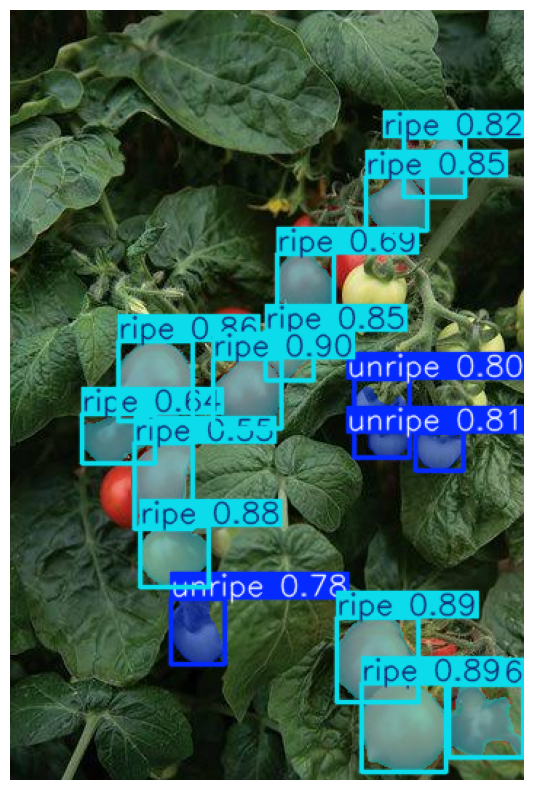

In [12]:
result_image = results[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

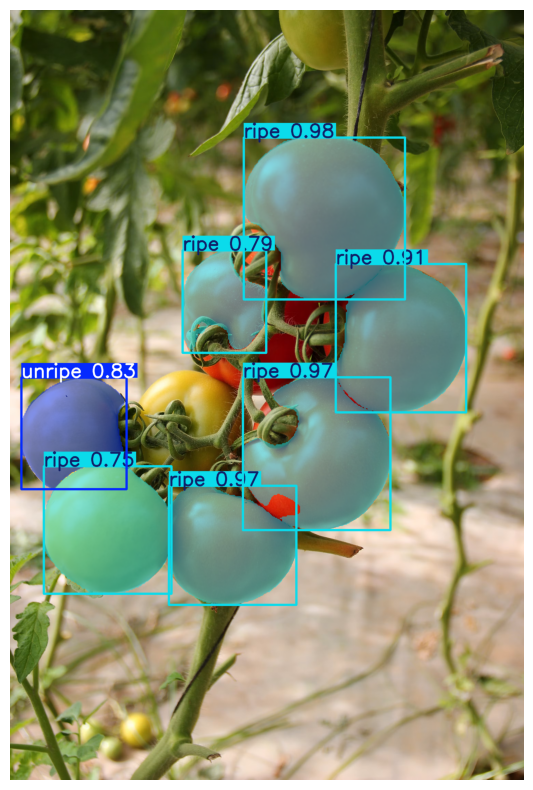

In [37]:
result_image = results1[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

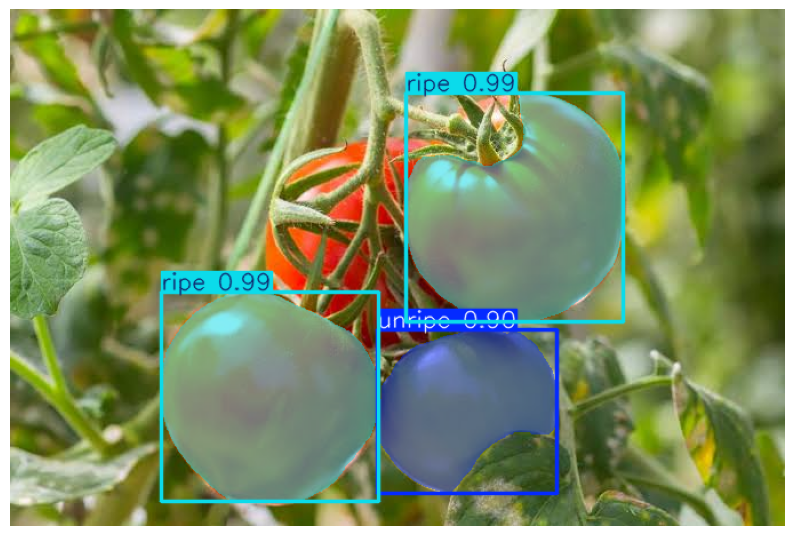

In [38]:
result_image = results2[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

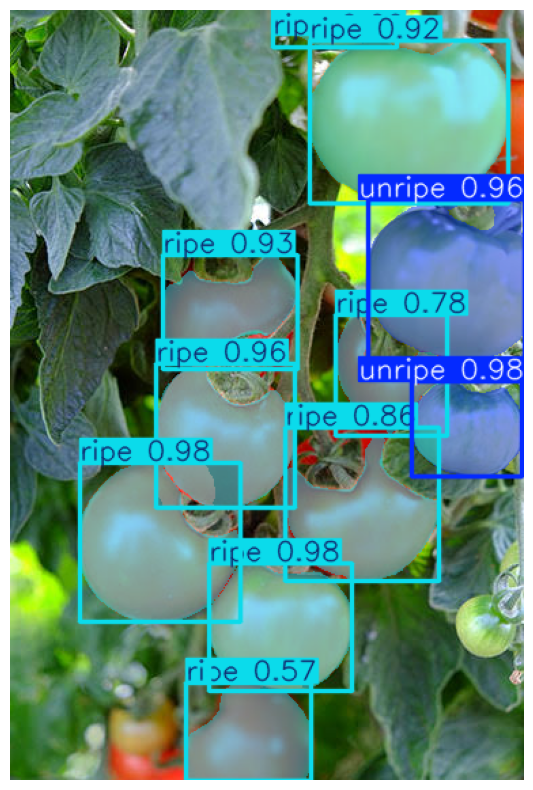

In [39]:
result_image = results3[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

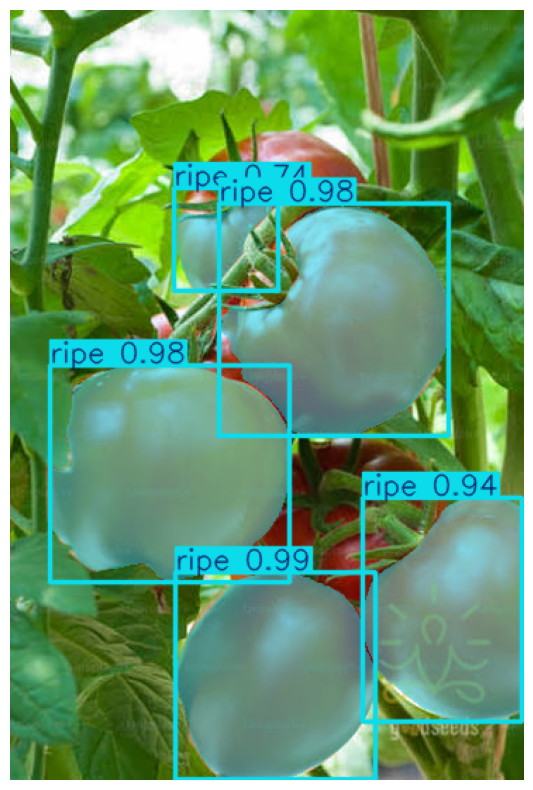

In [40]:
result_image = results4[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

###Count Total Tomatoes

In [13]:
boxes = results[0].boxes

print("Total Tomatoes Detected:", len(boxes))

Total Tomatoes Detected: 15


###Count Ripe and Unripe Tomatoes

In [14]:
ripe = 0
unripe = 0

for box in boxes:

    class_id = int(box.cls[0])

    if class_id == 0:
        unripe += 1
    else:
        ripe += 1

print("Ripe Tomatoes :", ripe)
print("Unripe Tomatoes :", unripe)

Ripe Tomatoes : 12
Unripe Tomatoes : 3


###Print Confidence Scores

In [15]:
names = model.names

for box in boxes:

    class_id = int(box.cls[0])

    confidence = float(box.conf[0])

    print(
        names[class_id],
        round(confidence,3)
    )

ripe 0.903
ripe 0.891
ripe 0.888
ripe 0.883
ripe 0.859
ripe 0.851
ripe 0.847
ripe 0.823
unripe 0.81
unripe 0.8
unripe 0.784
ripe 0.763
ripe 0.693
ripe 0.635
ripe 0.551


###Print Complete Detection Summary

In [18]:
print("="*50)
print("TOMATO DETECTION SUMMARY")
print("="*50)

print(f"Total Tomatoes : {len(boxes)}")
print(f"Ripe Tomatoes : {ripe}")
print(f"Unripe Tomatoes : {unripe}")

print("\nIndividual Predictions\n")

for i, box in enumerate(boxes):

    class_id = int(box.cls[0])

    confidence = float(box.conf[0])

    print(
        f"Tomato {i+1}: {names[class_id]} ({confidence:.2%})"
    )

TOMATO DETECTION SUMMARY
Total Tomatoes : 15
Ripe Tomatoes : 12
Unripe Tomatoes : 3

Individual Predictions

Tomato 1: ripe (90.30%)
Tomato 2: ripe (89.06%)
Tomato 3: ripe (88.82%)
Tomato 4: ripe (88.27%)
Tomato 5: ripe (85.88%)
Tomato 6: ripe (85.14%)
Tomato 7: ripe (84.68%)
Tomato 8: ripe (82.31%)
Tomato 9: unripe (80.99%)
Tomato 10: unripe (80.01%)
Tomato 11: unripe (78.42%)
Tomato 12: ripe (76.27%)
Tomato 13: ripe (69.26%)
Tomato 14: ripe (63.51%)
Tomato 15: ripe (55.08%)


###Saving the Predicted Image

In [20]:
save_path = "/content/drive/MyDrive/tomato_project/inference_result.jpg"

cv2.imwrite(save_path, result_image)

print("Prediction saved successfully!")

Prediction saved successfully!
